# Cross-validation against brutus

[brutus](https://github.com/joshspeagle/brutus) (Speagle et al.) fits stellar
photometry + parallax against MIST isochrone grids with a "brute force" Bayesian
scan — the closest published analog to tengri-stars' photometry channel. Here we
build **one mock star from brutus's own SED physics** (its C3K neural network),
fit it with both codes, and overlay the posteriors.

The comparison is deliberately not identical-by-construction:

| | brutus | tengri-stars |
|---|---|---|
| model space | MIST manifold (mass, EEP, [Fe/H]) | free atmosphere box (Teff, log g, [Fe/H]) |
| priors | IMF + age weights + Galactic structure + parallax | flat box + dilution nuisance |
| sampler | weighted grid scan | nested slice sampling (tengri NSS) |

So we *expect* brutus to be tighter wherever stellar-evolution priors inform the
fit (log g above all) and the two to agree on what the photometry alone
constrains. That gap is precisely what tengri-stars' planned isochrone-prior
plug-in will close.

In [1]:
import os

# JAX's XLA and numba's default OpenMP threading layer both load libomp —
# a duplicate-runtime segfault on macOS. numba's workqueue layer avoids libomp.
os.environ.setdefault("NUMBA_THREADING_LAYER", "workqueue")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import time

import corner
import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from brutus import utils as brutus_utils
from brutus.analysis import BruteForce
from brutus.core.individual import StarGrid
from brutus.core.neural_nets import FastNNPredictor
from brutus.data.download import fetch_grids, fetch_nns
from brutus.data.loader import load_models
from tengri import Uniform
from tengri.utils import edges_for_grid

from tengri_stars import PhotometryGrid, StarModel, fit_nss

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(9)

W0709 20:23:01.820177 35952530 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 1. Data files (cached after first download)

In [2]:
NN_FILE = str(fetch_nns(target_dir="data/brutus", model="c3k"))
GRID_FILE = str(fetch_grids(grid="mist_v9", target_dir="data/brutus"))

BANDS = ["PS_g", "PS_r", "PS_i", "PS_z", "PS_y", "2MASS_J", "2MASS_H", "2MASS_Ks"]
nn = FastNNPredictor(filters=BANDS, nnfile=NN_FILE, verbose=False)

## 2. Mock star from brutus's own SED physics

A metal-poor lower-RGB giant (L from log g and a 0.8 M☉ mass), 10 kpc away with
a Gaia-like parallax, A_V = 0.05 fixed to truth in both codes.

In [3]:
TRUTH = {"teff": 4600.0, "logg": 2.2, "feh": -1.5, "logl": np.log10(56.0), "dist_pc": 10000.0}
AV_TRUE, RV_TRUE = 0.05, 3.3
SIG_MAG = 0.02
PLX_TRUE_MAS = 1000.0 / TRUTH["dist_pc"]
PLX_ERR_MAS = 0.02

mags_true = nn.sed(
    logt=np.log10(TRUTH["teff"]),
    logg=TRUTH["logg"],
    feh_surf=TRUTH["feh"],
    logl=TRUTH["logl"],
    afe=0.0,
    av=AV_TRUE,
    rv=RV_TRUE,
    dist=TRUTH["dist_pc"],
)
mags_obs = mags_true + rng.normal(0.0, SIG_MAG, len(BANDS))
plx_obs = PLX_TRUE_MAS + rng.normal(0.0, PLX_ERR_MAS)
print("observed mags:", dict(zip(BANDS, np.round(mags_obs, 3))))
print(f"observed parallax: {plx_obs:.4f} ± {PLX_ERR_MAS} mas")

observed mags: {'PS_g': np.float64(16.213), 'PS_r': np.float64(15.555), 'PS_i': np.float64(15.21), 'PS_z': np.float64(15.113), 'PS_y': np.float64(15.034), '2MASS_J': np.float64(13.967), '2MASS_H': np.float64(13.345), '2MASS_Ks': np.float64(13.269)}
observed parallax: 0.0921 ± 0.02 mas


## 3. brutus fit (BruteForce over the MIST v9 grid)

In [4]:
models, labels, label_mask = load_models(GRID_FILE, filters=BANDS, verbose=False)
star_grid = StarGrid(models, labels, filters=BANDS, verbose=False)
bf = BruteForce(star_grid, verbose=False)

flux_obs, flux_err = brutus_utils.inv_magnitude(mags_obs, np.full(len(BANDS), SIG_MAG))

t0 = time.time()
bf.fit(
    flux_obs[None, :],
    flux_err[None, :],
    np.ones((1, len(BANDS)), dtype=bool),
    np.array([0]),  # object ID (h5py rejects unicode labels)
    "data/brutus/mock_fit",
    parallax=np.array([plx_obs]),
    parallax_err=np.array([PLX_ERR_MAS]),
    data_coords=np.array([[90.0, 60.0]]),  # halo sightline for the Galactic prior
    av_gauss=(AV_TRUE, 0.01),  # extinction pinned near truth, as in tengri-stars
    Ndraws=1000,
    rstate=np.random.RandomState(4),
    verbose=True,
)
brutus_wall = time.time() - t0
print(f"brutus wall time: {brutus_wall:.1f} s")

Fitting object 1/1  

Fitting object 1/1 [chi2/n: 5.7/9] (mean time: 0.332 s/obj, total: 0.332 s)    


brutus wall time: 1.0 s


In [5]:
with h5py.File("data/brutus/mock_fit.h5", "r") as f:
    model_idx = f["model_idx"][0]
    dist_samps_kpc = f["samps_dist"][0]

brutus_samples = {
    "teff": 10.0 ** labels["logt"][model_idx],
    "logg": labels["logg"][model_idx],
    "feh": labels["feh"][model_idx],
}
print("brutus medians:", {k: round(float(np.median(v)), 3) for k, v in brutus_samples.items()})
print(
    f"brutus distance: {np.median(dist_samps_kpc):.2f} kpc (truth {TRUTH['dist_pc'] / 1000:.1f})"
)

brutus medians: {'teff': 4623.732, 'logg': 2.039, 'feh': -0.85}
brutus distance: 12.43 kpc (truth 10.0)


## 4. tengri-stars fit on a grid built from the same physics

Rectangular (Teff, log g, [Fe/H]) grid tabulated straight from the same C3K
neural network (A_V baked at truth), then the standard NSS fit. The dilution
nuisance μ absorbs log L and distance — parallax does not enter (that requires
the isochrone prior linking log g to luminosity, the planned phase-2 plug-in).

In [6]:
teff_nodes = np.linspace(4000.0, 5500.0, 16)
logg_nodes = np.linspace(0.5, 5.0, 10)
feh_nodes = np.linspace(-2.4, 0.4, 15)
tt, gg, zz = np.meshgrid(teff_nodes, logg_nodes, feh_nodes, indexing="ij")

mags_grid = nn.sed_batch(
    logt=np.log10(tt.ravel()),
    logg=gg.ravel(),
    feh_surf=zz.ravel(),
    logl=np.zeros(tt.size),
    afe=np.zeros(tt.size),
    av=AV_TRUE,
    rv=RV_TRUE,
    dist=1000.0,
).reshape(*tt.shape, len(BANDS))

axes = tuple(jnp.asarray(a) for a in (teff_nodes, logg_nodes, feh_nodes))
phot_grid = PhotometryGrid(
    axes=axes,
    edges=tuple(edges_for_grid(a) for a in axes),
    phot=jnp.asarray(mags_grid),
    filter_names=tuple(BANDS),
    coverage=jnp.ones(tt.shape, bool),
)
model = StarModel(grid=phot_grid, interp_method="pchip")

priors = {
    "teff": Uniform(4000.0, 5500.0),
    "logg": Uniform(0.5, 5.0),
    "feh": Uniform(-2.4, 0.4),
    "mu": Uniform(-15.0, 15.0),
}
obs = jnp.asarray(mags_obs)


def loglikelihood(p):
    pred = model.predict_mags(teff=p["teff"], logg=p["logg"], feh=p["feh"], mu=p["mu"])
    return -0.5 * jnp.sum(((pred - obs) / SIG_MAG) ** 2)


t0 = time.time()
ts = fit_nss(loglikelihood, priors, key=jax.random.PRNGKey(21), n_live=400, num_delete=40)
print(
    f"tengri-stars NSS wall time: {time.time() - t0:.1f} s,  "
    f"log Z = {ts.logz:.1f}, ESS = {ts.ess:.0f}"
)
print("tengri-stars medians:", {k: round(v, 3) for k, v in ts.median().items()})

/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/brutus/core/neural_nets.py:272: RuntimeWarning: divide by zero encountered in matmul
  a1 = self.sigmoid(np.matmul(self.w1, self.encode(x)) + self.b1)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/brutus/core/neural_nets.py:272: RuntimeWarning: overflow encountered in matmul
  a1 = self.sigmoid(np.matmul(self.w1, self.encode(x)) + self.b1)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/brutus/core/neural_nets.py:272: RuntimeWarning: invalid value encountered in matmul
  a1 = self.sigmoid(np.matmul(self.w1, self.encode(x)) + self.b1)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/brutus/core/neural_nets.py:273: RuntimeWarning: divide by zero encountered in matmul
  a2 = self.sigmoid(np.matmul(self.w2, a1) + self.b2)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/brutus/core/neural_nets.py:273: RuntimeWarning: ov

W0709 20:23:04.935141 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:23:05.376103 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:23:06.365863 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:23:06.407267 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:23:06.412434 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:23:06.567407 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:23:07.046898 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:23:07.104455 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0709 20:23:07.775718 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:23:07.792868 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:23:07.876641 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:23:07.892465 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:23:07.959922 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:23:07.963653 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0709 20:23:07.966691 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


tengri-stars NSS wall time: 3.4 s,  log Z = -14.9, ESS = 1829
tengri-stars medians: {'teff': 4615.951, 'logg': 2.409, 'feh': -1.282, 'mu': 0.631}


W0709 20:23:07.995294 35952359 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 5. Posterior overlay

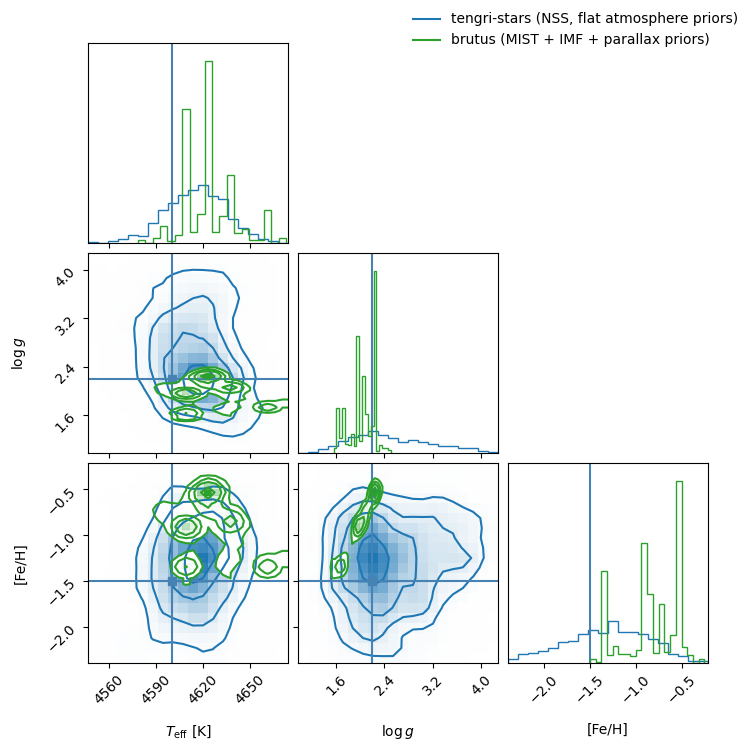

In [7]:
shared = ["teff", "logg", "feh"]
labels_tex = [r"$T_{\rm eff}$ [K]", r"$\log g$", "[Fe/H]"]
truth_vec = [TRUTH["teff"], TRUTH["logg"], TRUTH["feh"]]

b_stack = np.column_stack([np.asarray(brutus_samples[k], dtype=float) for k in shared])
t_stack = np.column_stack([np.asarray(ts.samples[k]) for k in shared])

fig = corner.corner(
    t_stack,
    labels=labels_tex,
    truths=truth_vec,
    color="C0",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    smooth=1.0,
)
corner.corner(
    b_stack,
    fig=fig,
    color="C2",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    smooth=1.0,
)
fig.legend(
    handles=[
        plt.Line2D([], [], color="C0", label="tengri-stars (NSS, flat atmosphere priors)"),
        plt.Line2D([], [], color="C2", label="brutus (MIST + IMF + parallax priors)"),
    ],
    loc="upper right",
    frameon=False,
)
plt.show()

In [8]:
print(f"{'':8s}{'truth':>9s}{'brutus':>22s}{'tengri-stars':>22s}")
for k, tv in zip(shared, truth_vec):
    b = np.percentile(np.asarray(brutus_samples[k], dtype=float), [16, 50, 84])
    t = np.percentile(np.asarray(ts.samples[k]), [16, 50, 84])
    print(
        f"{k:8s}{tv:9.2f}{b[1]:10.2f} [{b[0]:7.2f},{b[2]:7.2f}]"
        f"{t[1]:10.2f} [{t[0]:7.2f},{t[2]:7.2f}]"
    )

            truth                brutus          tengri-stars
teff      4600.00   4623.73 [4608.87,4639.36]   4615.95 [4596.41,4633.16]
logg         2.20      2.04 [   1.73,   2.25]      2.41 [   1.86,   3.26]
feh         -1.50     -0.85 [  -1.25,  -0.55]     -1.28 [  -1.78,  -0.86]


## Reading the comparison (observed on this mock)

- **Teff agrees** to ~10 K between the two codes (truth covered by both) —
  broadband colors carry the temperature and both likelihoods see the same
  photometry.
- **log g: brutus is ~2.6× tighter** (68% width ≈ 0.5 vs 1.4 dex), both
  covering truth. That is the MIST manifold + IMF prior at work, not better
  photometric information. This gap is the measurable case for tengri-stars'
  planned isochrone-prior plug-in (`distance={'type': 'isochrone'}`).
- **[Fe/H] is the cautionary tale**: grizy + JHK photometry constrains
  metallicity weakly, so *priors dominate the marginal* — brutus's pull it
  metal-rich far enough that truth (−1.5) falls outside its 68% interval
  (median −0.85), while the flat-prior posterior stays centered near truth with
  honest width. This is a quantitative demonstration of why MAGIC's CaHK band
  exists: add a metallicity-sensitive band and the likelihood, not the prior,
  decides.
- **Distance**: brutus infers it (parallax + priors); tengri-stars' μ absorbs
  it by design until the isochrone plug-in links log g to luminosity.
- **Caveats**: brutus samples [Fe/H]_initial on the MIST manifold while
  tengri-stars fits the surface abundance the NN sees (diffusion-level
  difference); brutus's equal-weight draws quantize its contours; the mock came
  from the same C3K NN brutus uses, so neither code carries model mismatch.